# Disease Symptom Prediction - Exploratory Data Analysis

## Project

AI Disease Prediction System

## Objective

The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the cleaned Disease Symptom Prediction dataset.

The analysis focuses on understanding:

- Dataset structure and quality
- Disease/class distribution
- Symptom frequency
- Missing symptom patterns
- Symptom count distribution
- Disease-symptom relationships
- Symptom co-occurrence patterns
- Potential data quality issues

The findings from this notebook will guide feature selection, preprocessing, and model development.

---

**Author:** Shahbaj Tanvir Shawon

**Course:** CSE Project

**Notebook:** 02_EDA.ipynb

# 1. Import Required Libraries

This section imports the Python libraries required for:

- Data manipulation
- Numerical analysis
- Data visualization
- Statistical exploration
- File and path management

In [1]:
# Suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# File and path handling
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Set visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Project Paths and Configuration

The processed dataset generated by `01_Data_Cleaning.ipynb` is used as the input for this EDA notebook.

Project-relative paths are used so that the notebook remains portable across different environments.

In [2]:
# -------------------------------
# Project Paths
# -------------------------------

PROJECT_ROOT = Path("../")

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
EDA_OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "eda_outputs"

# Create EDA output directory
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Dataset configuration
DATA_FILE = PROCESSED_DATA_DIR / "disease_clean.csv"

TARGET_COLUMN = "Disease"

print("Project configuration completed.")
print(f"Processed dataset: {DATA_FILE}")
print(f"EDA output directory: {EDA_OUTPUT_DIR}")

Project configuration completed.
Processed dataset: ..\data\processed\disease_clean.csv
EDA output directory: ..\data\processed\eda_outputs


# 3. Load Processed Dataset

The cleaned dataset generated during the data-cleaning stage is loaded for exploratory analysis.

Using the processed dataset ensures that the EDA is performed on the same data that will be used during subsequent model development.

In [3]:
# Load processed dataset
df = pd.read_csv(DATA_FILE)

print("Processed dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Processed dataset loaded successfully!
Dataset shape: (4920, 19)


# 4. Dataset Overview

Before performing detailed analysis, we inspect the basic structure of the dataset.

The following information will be examined:

- Number of observations
- Number of features
- Column names
- Data types
- Memory usage

In [4]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

DATASET OVERVIEW
Number of Rows    : 4920
Number of Columns : 19

Column Names:
['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17', 'Symptom_Count']

Data Types:
Disease          object
Symptom_1        object
Symptom_2        object
Symptom_3        object
Symptom_4        object
Symptom_5        object
Symptom_6        object
Symptom_7        object
Symptom_8        object
Symptom_9        object
Symptom_10       object
Symptom_11       object
Symptom_12       object
Symptom_13       object
Symptom_14       object
Symptom_15       object
Symptom_16       object
Symptom_17       object
Symptom_Count     int64
dtype: object


# 5. Preview the Dataset

A small sample of the dataset is displayed to verify that the processed data has been loaded correctly.

In [5]:
df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17,Symptom_Count
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3


# 6. Dataset Statistical Summary

The dataset primarily contains categorical symptom and disease information.

A general statistical summary is generated to understand:

- Number of unique values
- Most frequent values
- Frequency of the most common category

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Disease,4920,41,Fungal infection,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_1,4920,34,vomiting,822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_2,4920,48,vomiting,870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_3,4920,54,fatigue,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_4,4572,50,high_fever,378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_5,3714,38,headache,348,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_6,2934,32,nausea,390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_7,2268,26,abdominal_pain,264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_8,1944,21,abdominal_pain,276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_9,1692,22,yellowing_of_eyes,228,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 7. Missing Value Analysis

Missing values are expected in the symptom columns because a patient record does not necessarily contain all 17 possible symptom positions.

Therefore, missing values are analyzed rather than automatically removed.

We calculate:

- Number of missing values
- Percentage of missing values

In [7]:
missing_analysis = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage (%)": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_analysis = missing_analysis.sort_values(
    by="Missing Values",
    ascending=False
)

missing_analysis

,Missing Values,Missing Percentage (%)
Symptom_17,4848,98.54
Symptom_16,4728,96.10
Symptom_15,4680,95.12
Symptom_14,4614,93.78
Symptom_13,4416,89.76
Symptom_12,4176,84.88
Symptom_11,3726,75.73
Symptom_10,3408,69.27
Symptom_9,3228,65.61
Symptom_8,2976,60.49


## Missing Value Visualization

The following visualization shows the number of missing values in each column.

This helps identify whether missing values are concentrated in specific symptom columns.

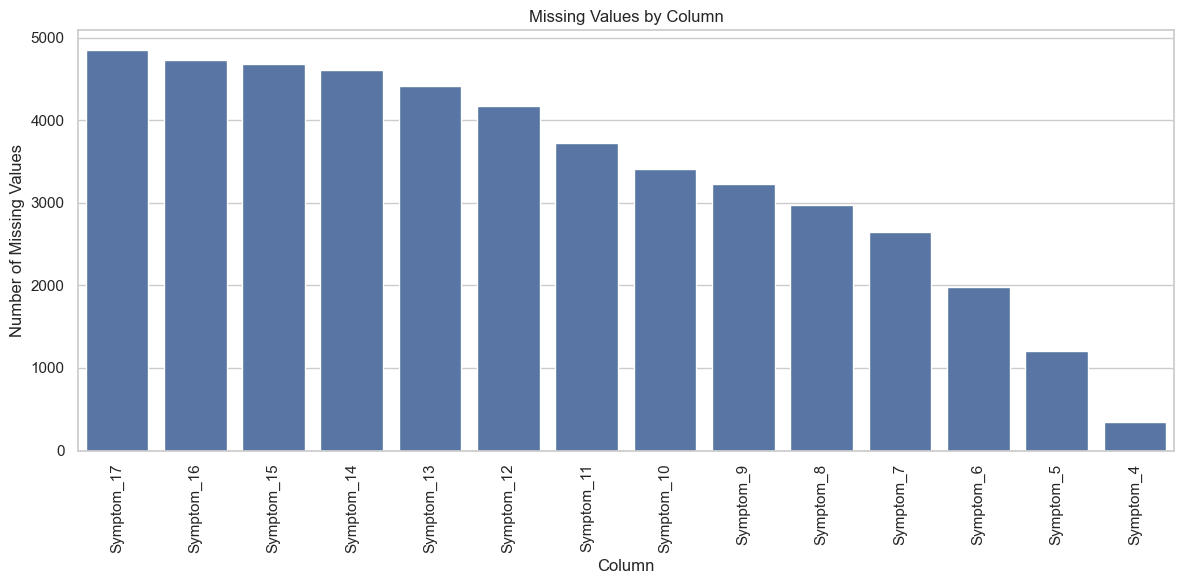

In [8]:
missing_plot = missing_analysis[
    missing_analysis["Missing Values"] > 0
]

plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing_plot.index,
    y=missing_plot["Missing Values"]
)

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# 8. Target Variable Analysis

The target variable is `Disease`.

The purpose of this analysis is to determine:

- Number of unique disease classes
- Number of records per disease
- Whether the target distribution is balanced

In [9]:
# Disease class distribution
disease_counts = df[TARGET_COLUMN].value_counts()

print(f"Number of Disease Classes: {df[TARGET_COLUMN].nunique()}")

print("\nDisease Distribution:")
disease_counts

Number of Disease Classes: 41

Disease Distribution:


Disease
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                                120
Hepat

## Target Class Balance

A multi-class classification problem should be examined for class imbalance.

A balanced target distribution means that the model is less likely to favor particular disease classes simply because they contain substantially more training examples.

In [10]:
# Calculate class distribution percentages
class_distribution = pd.DataFrame({
    "Count": disease_counts,
    "Percentage (%)": (
        disease_counts / len(df) * 100
    ).round(2)
})

class_distribution

,Count,Percentage (%)
Disease,,
Fungal infection,120,2.44
Allergy,120,2.44
GERD,120,2.44
Chronic cholestasis,120,2.44
Drug Reaction,120,2.44
Peptic ulcer diseae,120,2.44
AIDS,120,2.44
Diabetes,120,2.44
Gastroenteritis,120,2.44


## Disease Distribution Visualization

The distribution of disease classes is visualized to make differences in class frequency easier to identify.

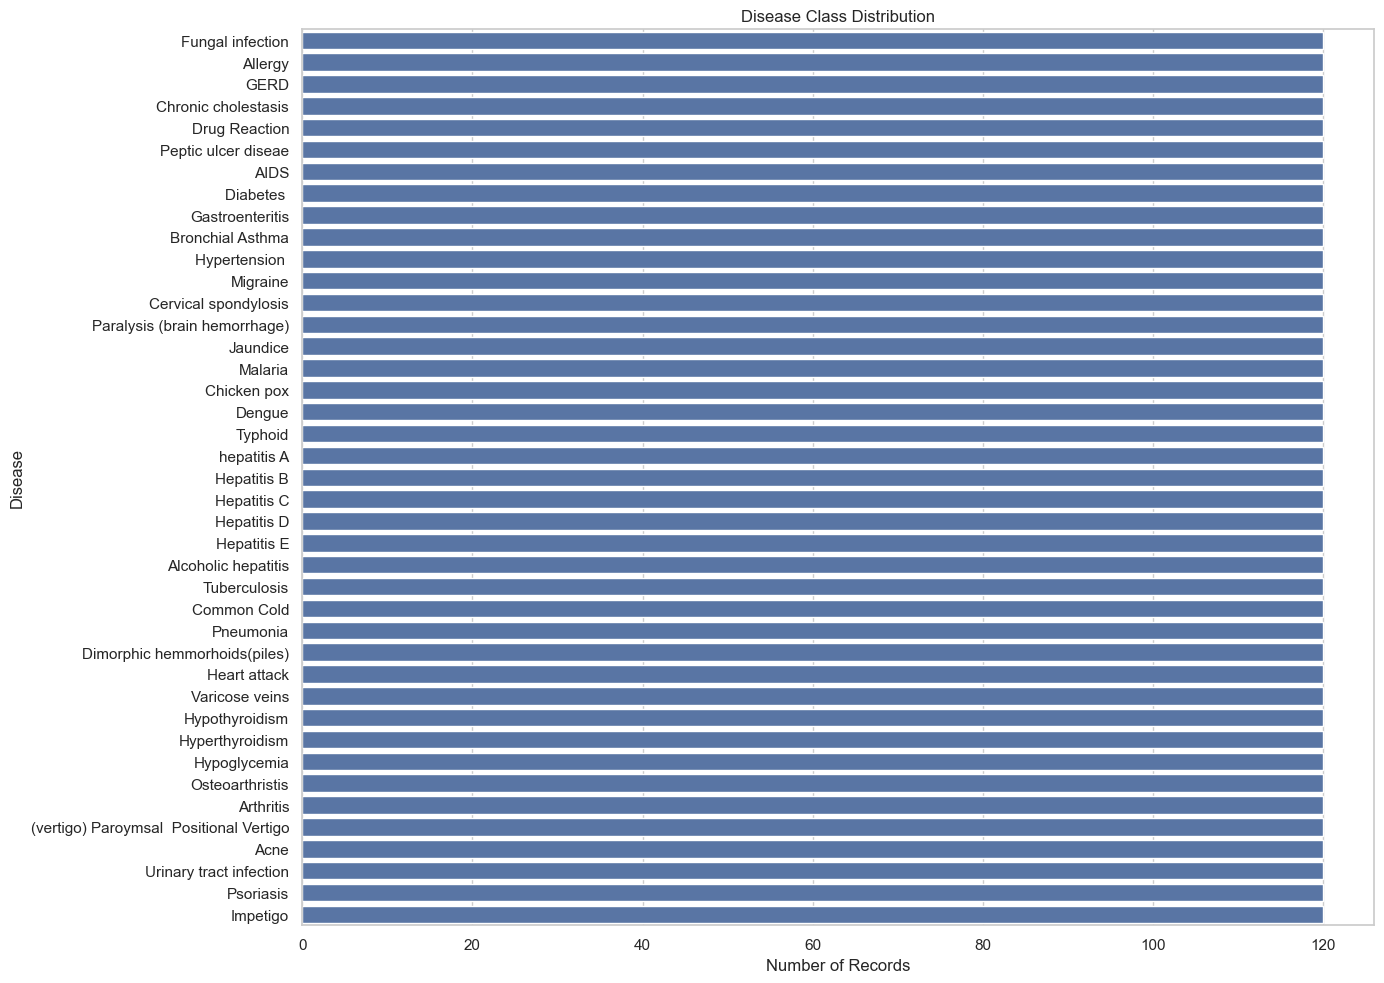

In [11]:
plt.figure(figsize=(14, 10))

sns.barplot(
    x=disease_counts.values,
    y=disease_counts.index
)

plt.title("Disease Class Distribution")
plt.xlabel("Number of Records")
plt.ylabel("Disease")

plt.tight_layout()
plt.show()

# 9. Symptom Frequency Analysis

The symptom columns contain the symptoms associated with each disease record.

To understand the importance and frequency of individual symptoms, all symptom columns are combined into a single series.

This allows us to determine:

- Most frequently occurring symptoms
- Least frequently occurring symptoms
- Overall symptom distribution

In [12]:
# Identify symptom columns
symptom_columns = [
    column for column in df.columns
    if column.startswith("Symptom_")
]

print(f"Number of symptom columns: {len(symptom_columns)}")
print("\nSymptom columns:")
print(symptom_columns)

Number of symptom columns: 18

Symptom columns:
['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17', 'Symptom_Count']


In [13]:
# Combine all symptom columns
all_symptoms = df[symptom_columns].stack().dropna()

# Count symptom frequency
symptom_frequency = all_symptoms.value_counts()

print(f"Unique symptoms found: {symptom_frequency.nunique()}")
print("\nTop 20 Most Frequent Symptoms:")

symptom_frequency.head(20)

Unique symptoms found: 45

Top 20 Most Frequent Symptoms:


fatigue              1932
vomiting             1914
high_fever           1362
loss_of_appetite     1152
nausea               1146
headache             1134
abdominal_pain       1032
yellowish_skin        912
4                     858
yellowing_of_eyes     816
chills                798
skin_rash             786
5                     780
malaise               702
chest_pain            696
joint_pain            684
itching               678
sweating              678
6                     666
dark_urine            570
Name: count, dtype: int64

## Top Symptoms Visualization

The most frequently occurring symptoms are visualized to identify the symptoms that appear most often across the dataset.

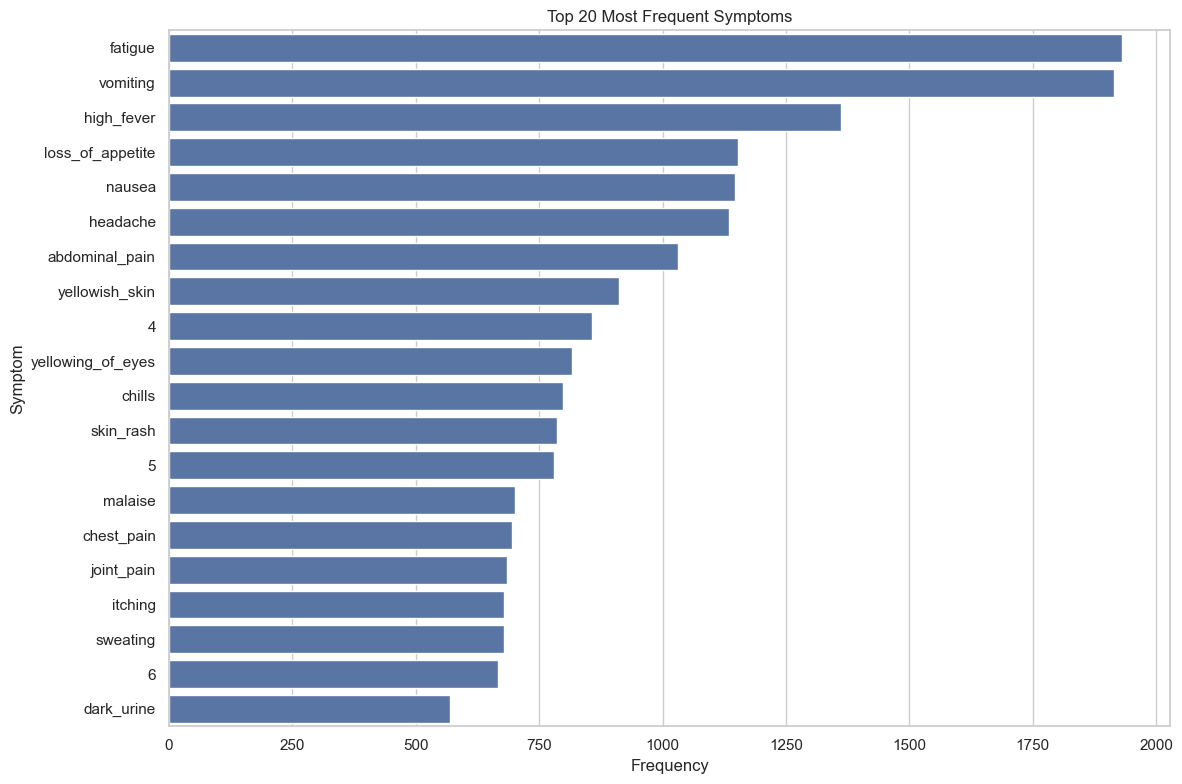

In [14]:
top_symptoms = symptom_frequency.head(20)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=top_symptoms.values,
    y=top_symptoms.index
)

plt.title("Top 20 Most Frequent Symptoms")
plt.xlabel("Frequency")
plt.ylabel("Symptom")

plt.tight_layout()
plt.show()

# 10. Symptom Count Analysis

`Symptom_Count` was created during the data-cleaning and feature-engineering stage.

It represents the total number of reported symptoms for each record.

Analyzing this feature helps us understand the distribution of symptom burden across the dataset.

In [15]:
df["Symptom_Count"].describe()

count    4920.000000
mean        7.448780
std         3.592166
min         3.000000
25%         5.000000
50%         6.000000
75%        10.000000
max        17.000000
Name: Symptom_Count, dtype: float64

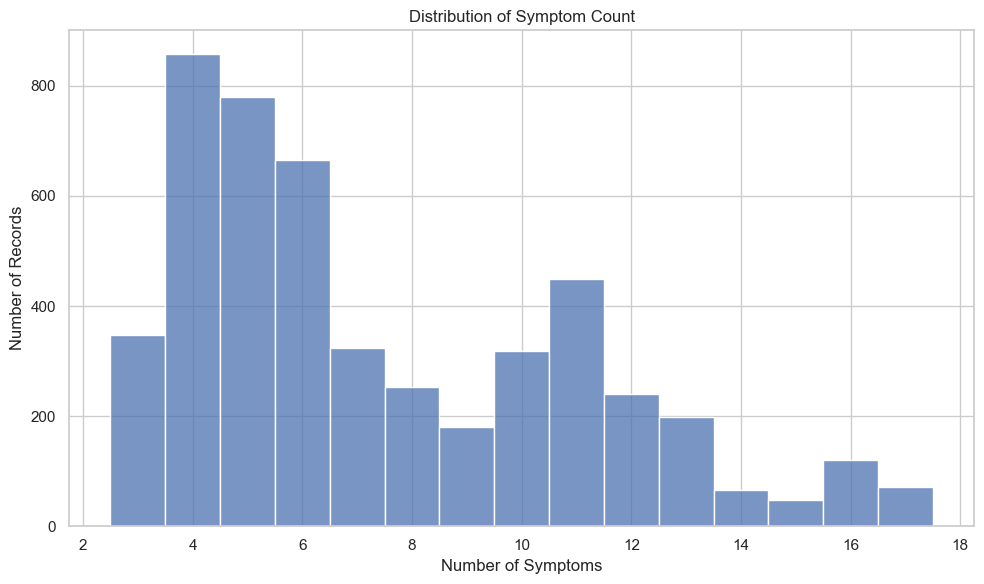

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Symptom_Count",
    bins=17,
    discrete=True
)

plt.title("Distribution of Symptom Count")
plt.xlabel("Number of Symptoms")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

## Symptom Count by Disease

Different diseases may be associated with different numbers of reported symptoms.

We therefore examine the average symptom count for each disease.

In [17]:
symptom_count_by_disease = (
    df.groupby(TARGET_COLUMN)["Symptom_Count"]
    .agg(["mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

symptom_count_by_disease

,mean,median,min,max
Disease,,,,
Common Cold,16.60,17.0,16,17
Tuberculosis,15.60,16.0,15,16
Dengue,13.55,14.0,13,14
Hepatitis E,12.60,13.0,12,13
Hypothyroidism,12.60,13.0,12,13
Hypoglycemia,11.60,12.0,11,12
Hepatitis B,11.60,12.0,11,12
Hyperthyroidism,10.60,11.0,10,11
Pneumonia,10.60,11.0,10,11


## Average Symptom Count by Disease

The following visualization shows the average number of symptoms associated with each disease class.

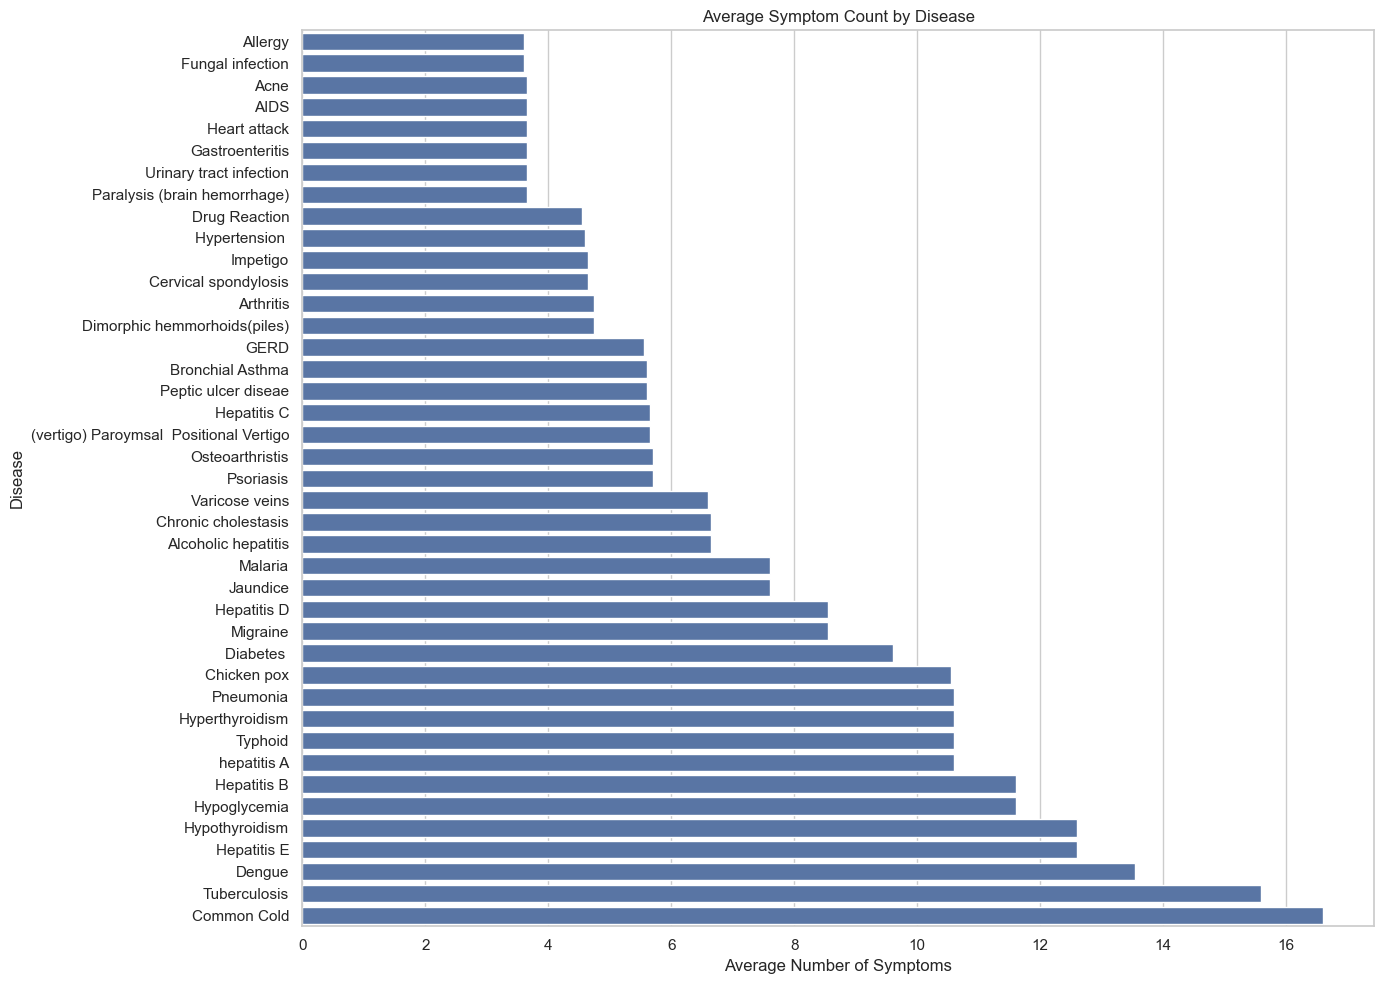

In [18]:
mean_symptoms = (
    df.groupby(TARGET_COLUMN)["Symptom_Count"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(14, 10))

sns.barplot(
    x=mean_symptoms.values,
    y=mean_symptoms.index
)

plt.title("Average Symptom Count by Disease")
plt.xlabel("Average Number of Symptoms")
plt.ylabel("Disease")

plt.tight_layout()
plt.show()

# 11. Disease-Symptom Relationship Analysis

The relationship between diseases and symptoms is one of the most important aspects of this dataset.

For selected diseases, we analyze which symptoms occur most frequently.

This provides domain-oriented insight into the symptom patterns associated with different disease classes.

In [19]:
# Select the five most common disease classes
top_diseases = disease_counts.head(5).index.tolist()

print("Selected diseases:")
for disease in top_diseases:
    print("-", disease)

Selected diseases:
- Fungal infection
- Allergy
- GERD
- Chronic cholestasis
- Drug Reaction


In [20]:
# Select the five most common disease classes
top_diseases = disease_counts.head(5).index.tolist()

print("Selected diseases:")
for disease in top_diseases:
    print("-", disease)

Selected diseases:
- Fungal infection
- Allergy
- GERD
- Chronic cholestasis
- Drug Reaction


# 12. Symptom Co-occurrence Analysis

Symptoms can occur together within the same patient record.

Studying symptom co-occurrence can reveal meaningful symptom combinations and may help identify useful feature interactions for future model development.

For example:

- Fever + fatigue
- Cough + breathing difficulty
- Headache + nausea

The following analysis identifies the most common pairs of symptoms appearing together.

In [21]:
# 14. Symptom Co-occurrence Analysis

from itertools import combinations
from collections import Counter

# Store frequency of symptom pairs
pair_counter = Counter()

# Process each patient's symptoms
for _, row in df[symptom_columns].iterrows():

    # Clean and normalize symptoms
    symptoms = []

    for symptom in row:
        if pd.notna(symptom):
            symptom = str(symptom).strip().lower()

            # Ignore empty values and invalid placeholder values
            if symptom not in ["", "nan", "none"]:
                symptoms.append(symptom)

    # Remove duplicate symptoms within the same patient
    symptoms = sorted(set(symptoms))

    # Generate unique symptom pairs
    for pair in combinations(symptoms, 2):
        pair_counter[pair] += 1

# Convert results into a DataFrame
cooccurrence = pd.DataFrame(
    pair_counter.items(),
    columns=["Symptom_Pair", "Frequency"]
)

# Sort by frequency
cooccurrence = cooccurrence.sort_values(
    by="Frequency",
    ascending=False
).reset_index(drop=True)

print("Symptom co-occurrence analysis completed successfully.")
print(f"Total unique symptom pairs: {len(cooccurrence)}")

cooccurrence.head(20)

Symptom co-occurrence analysis completed successfully.
Total unique symptom pairs: 1428


,Symptom_Pair,Frequency
0,"(fatigue, high_fever)",978
1,"(nausea, vomiting)",978
2,"(abdominal_pain, vomiting)",870
3,"(loss_of_appetite, yellowing_of_eyes)",786
4,"(fatigue, loss_of_appetite)",774
5,"(loss_of_appetite, vomiting)",768
6,"(abdominal_pain, yellowish_skin)",762
7,"(fatigue, vomiting)",762
8,"(fatigue, malaise)",666
9,"(loss_of_appetite, nausea)",666


## Most Common Symptom Pairs

The most frequently occurring symptom pairs are visualized below.

In [22]:
# Prepare symptom co-occurrence data for visualization

cooccurrence_plot = cooccurrence.copy()

# Convert symptom pair tuples into readable text
cooccurrence_plot["Pair"] = cooccurrence_plot["Symptom_Pair"].apply(
    lambda x: " + ".join(x)
)

# Select top 10 symptom pairs
top_pairs = cooccurrence_plot.head(10)

top_pairs

,Symptom_Pair,Frequency,Pair
0,"(fatigue, high_fever)",978,fatigue + high_fever
1,"(nausea, vomiting)",978,nausea + vomiting
2,"(abdominal_pain, vomiting)",870,abdominal_pain + vomiting
3,"(loss_of_appetite, yellowing_of_eyes)",786,loss_of_appetite + yellowing_of_eyes
4,"(fatigue, loss_of_appetite)",774,fatigue + loss_of_appetite
5,"(loss_of_appetite, vomiting)",768,loss_of_appetite + vomiting
6,"(abdominal_pain, yellowish_skin)",762,abdominal_pain + yellowish_skin
7,"(fatigue, vomiting)",762,fatigue + vomiting
8,"(fatigue, malaise)",666,fatigue + malaise
9,"(loss_of_appetite, nausea)",666,loss_of_appetite + nausea


# 13. Symptom-Disease Frequency Matrix

To better understand the relationship between diseases and symptoms, we construct a frequency matrix.

Each row represents a disease and each column represents a symptom.

The value represents how frequently a symptom appears within the records of a disease.

In [23]:
# Create disease-symptom frequency matrix

# --------------------------------------------------
# Step 1: Normalize all symptom values
# --------------------------------------------------

normalized_symptoms = (
    df[symptom_columns]
    .stack()
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
)

# Remove invalid or empty values
normalized_symptoms = normalized_symptoms[
    ~normalized_symptoms.isin(["", "nan", "none"])
]

# --------------------------------------------------
# Step 2: Get unique symptoms
# --------------------------------------------------

unique_symptoms = sorted(
    normalized_symptoms.unique()
)

# --------------------------------------------------
# Step 3: Get unique disease names
# --------------------------------------------------

unique_diseases = sorted(
    df[TARGET_COLUMN]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

# --------------------------------------------------
# Step 4: Initialize the matrix
# --------------------------------------------------

disease_symptom_matrix = pd.DataFrame(
    0,
    index=unique_diseases,
    columns=unique_symptoms
)

# --------------------------------------------------
# Step 5: Populate the matrix
# --------------------------------------------------

for disease in unique_diseases:

    # Select records belonging to the disease
    disease_data = df[
        df[TARGET_COLUMN]
        .astype(str)
        .str.strip()
        == disease
    ]

    # Extract symptoms
    disease_symptoms = (
        disease_data[symptom_columns]
        .stack()
        .dropna()
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # Remove invalid values
    disease_symptoms = disease_symptoms[
        ~disease_symptoms.isin(["", "nan", "none"])
    ]

    # Count symptom occurrences
    symptom_counts = disease_symptoms.value_counts()

    # Store counts in the matrix
    for symptom, count in symptom_counts.items():

        if symptom in disease_symptom_matrix.columns:
            disease_symptom_matrix.loc[
                disease, symptom
            ] = count


# --------------------------------------------------
# Step 6: Display results
# --------------------------------------------------

print("Disease-symptom frequency matrix created successfully.")

print(f"Number of diseases : {disease_symptom_matrix.shape[0]}")
print(f"Number of symptoms : {disease_symptom_matrix.shape[1]}")
print(f"Matrix shape       : {disease_symptom_matrix.shape}")

disease_symptom_matrix.head()

Disease-symptom frequency matrix created successfully.
Number of diseases : 41
Number of symptoms : 146
Matrix shape       : (41, 146)


,10,11,12,13,14,15,16,17,3,4,5,6,7,8,9,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,bladder_discomfort,blister,blood_in_sputum,bloody_stool,blurred_and_distorted_vision,breathlessness,brittle_nails,bruising,burning_micturition,chest_pain,chills,cold_hands_and_feets,coma,congestion,constipation,continuous_feel_of_urine,continuous_sneezing,cough,cramps,dark_urine,dehydration,depression,diarrhoea,dischromic _patches,distention_of_abdomen,dizziness,drying_and_tingling_lips,enlarged_thyroid,excessive_hunger,extra_marital_contacts,family_history,fast_heart_rate,fatigue,fluid_overload,foul_smell_of urine,headache,high_fever,hip_joint_pain,history_of_alcohol_consumption,increased_appetite,indigestion,inflammatory_nails,internal_itching,irregular_sugar_level,irritability,irritation_in_anus,itching,joint_pain,knee_pain,lack_of_concentration,lethargy,loss_of_appetite,loss_of_balance,loss_of_smell,malaise,mild_fever,mood_swings,movement_stiffness,mucoid_sputum,muscle_pain,muscle_wasting,muscle_weakness,nausea,neck_pain,nodal_skin_eruptions,obesity,pain_behind_the_eyes,pain_during_bowel_movements,pain_in_anal_region,painful_walking,palpitations,passage_of_gases,patches_in_throat,phlegm,polyuria,prominent_veins_on_calf,puffy_face_and_eyes,pus_filled_pimples,receiving_blood_transfusion,receiving_unsterile_injections,red_sore_around_nose,red_spots_over_body,redness_of_eyes,restlessness,runny_nose,rusty_sputum,scurring,shivering,silver_like_dusting,sinus_pressure,skin_peeling,skin_rash,slurred_speech,small_dents_in_nails,spinning_movements,spotting_ urination,stiff_neck,stomach_bleeding,stomach_pain,sunken_eyes,sweating,swelled_lymph_nodes,swelling_joints,swelling_of_stomach,swollen_blood_vessels,swollen_extremeties,swollen_legs,throat_irritation,toxic_look_(typhos),ulcers_on_tongue,unsteadiness,visual_disturbances,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
(vertigo) Paroymsal Positional Vertigo,0,0,0,0,0,0,0,0,0,0,42,78,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,114,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,114,0,0,0,0,0,0,0,0,0,114,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,114,0,114,0,0,0,0,0,0,0,0,0
AIDS,0,0,0,0,0,0,0,0,42,78,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,114,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Acne,0,0,0,0,0,0,0,0,42,78,0,0,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,0,0,108,0,0,0,0,114,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Alcoholic hepatitis,0,0,0,0,0,0,0,0,0,0,0,42,78,0,0,114,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,114,0,0,0,0,0,0,0,0,114,0,0,0,0,114,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,114,0,0,0,0,0,0,0,0,114,0,0,0,0,0,0,0,0,114
Allergy,0,0,0,0,0,0,0,0,48,72,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,108,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,0,0


## Disease-Symptom Heatmap

A heatmap provides a visual representation of symptom frequency across disease classes.

Because the complete disease-symptom matrix may contain many symptoms, the visualization focuses on the most frequently occurring symptoms.

Higher values indicate that a symptom appears more frequently within records associated with a particular disease.

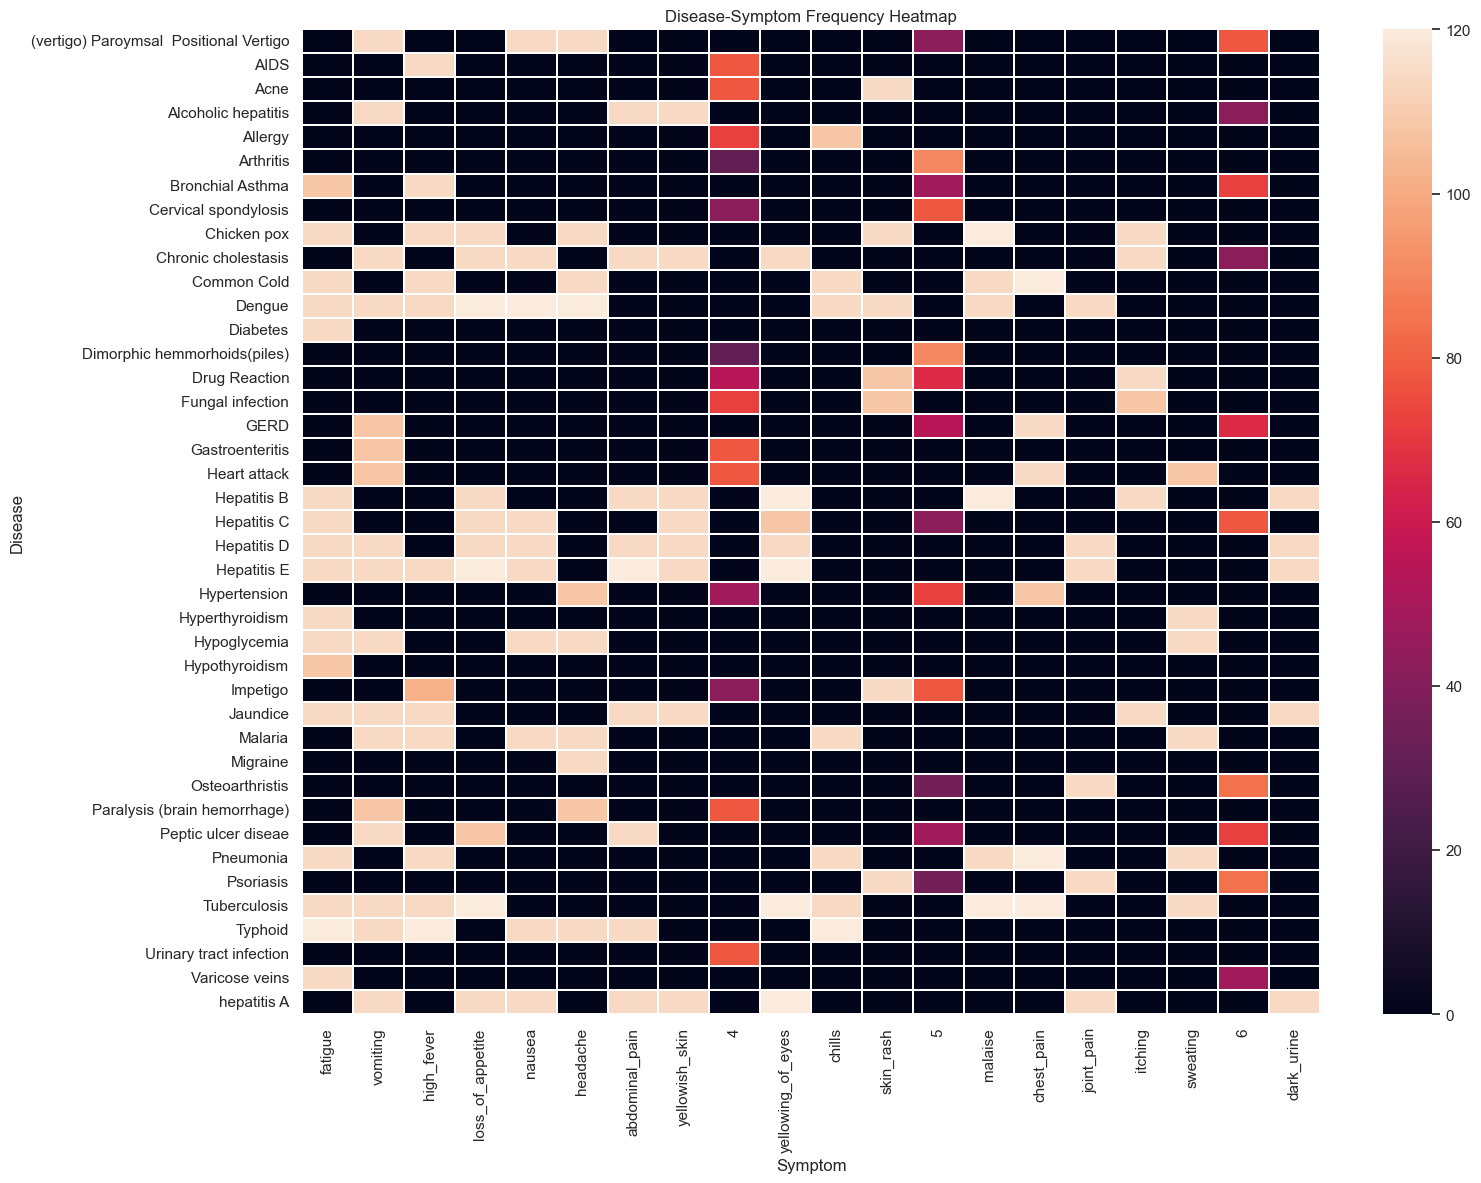

In [24]:
# Disease-Symptom Heatmap

# --------------------------------------------------
# Step 1: Normalize symptom values
# --------------------------------------------------

eda_symptoms = (
    df[symptom_columns]
    .stack()
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
)

# Remove invalid or empty values
eda_symptoms = eda_symptoms[
    ~eda_symptoms.isin(["", "nan", "none"])
]

# --------------------------------------------------
# Step 2: Find the 20 most frequent symptoms
# --------------------------------------------------

top_20_symptoms = (
    eda_symptoms
    .value_counts()
    .head(20)
    .index
    .tolist()
)

# --------------------------------------------------
# Step 3: Keep symptoms available in the matrix
# --------------------------------------------------

top_20_symptoms = [
    symptom
    for symptom in top_20_symptoms
    if symptom in disease_symptom_matrix.columns
]

# --------------------------------------------------
# Step 4: Prepare heatmap data
# --------------------------------------------------

heatmap_data = disease_symptom_matrix[
    top_20_symptoms
]

# --------------------------------------------------
# Step 5: Create heatmap
# --------------------------------------------------

plt.figure(figsize=(16, 12))

sns.heatmap(
    heatmap_data,
    linewidths=0.2
)

plt.title(
    "Disease-Symptom Frequency Heatmap"
)

plt.xlabel("Symptom")
plt.ylabel("Disease")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

# 14. Final Data Quality Checks

Before proceeding to machine learning model development, final data-quality
checks are performed.

The checks verify:

- Dataset dimensions
- Number of disease classes
- Missing values in the target variable
- Duplicate records
- Number of unique symptom patterns
- Validity of the `Symptom_Count` feature
- Minimum and maximum number of reported symptoms

The dataset contains many repeated records. Therefore, duplicate records are
not automatically removed.

Instead, duplicate and repeated symptom patterns will be handled during the
model-development stage using a duplicate-aware train/test strategy.

Missing values in symptom columns are expected because a patient record may
contain fewer than 17 symptoms.

In [25]:
print("=" * 60)
print("FINAL EDA DATA QUALITY CHECK")
print("=" * 60)

# --------------------------------------------------
# Basic dataset information
# --------------------------------------------------

print(f"Rows                  : {len(df)}")
print(f"Columns               : {len(df.columns)}")
print(f"Disease Classes       : {df[TARGET_COLUMN].nunique()}")

# --------------------------------------------------
# Target validation
# --------------------------------------------------

print(
    f"Target Missing Values : "
    f"{df[TARGET_COLUMN].isnull().sum()}"
)

# --------------------------------------------------
# Duplicate analysis
# --------------------------------------------------

duplicate_rows = df.duplicated().sum()

print(
    f"Duplicate Rows        : "
    f"{duplicate_rows}"
)

# --------------------------------------------------
# Unique symptom patterns
# --------------------------------------------------

eda_symptom_columns = [
    column
    for column in df.columns
    if column.startswith("Symptom_")
    and column != "Symptom_Count"
]

unique_symptom_patterns = (
    df[eda_symptom_columns]
    .fillna("__MISSING__")
    .astype(str)
    .drop_duplicates()
)

print(
    f"Unique Symptom Patterns: "
    f"{len(unique_symptom_patterns)}"
)

# --------------------------------------------------
# Symptom count range
# --------------------------------------------------

print(
    f"Minimum Symptom Count : "
    f"{df['Symptom_Count'].min()}"
)

print(
    f"Maximum Symptom Count : "
    f"{df['Symptom_Count'].max()}"
)

print("\n✓ Final EDA data-quality check completed.")

FINAL EDA DATA QUALITY CHECK
Rows                  : 4920
Columns               : 19
Disease Classes       : 41
Target Missing Values : 0
Duplicate Rows        : 4616
Unique Symptom Patterns: 304
Minimum Symptom Count : 3
Maximum Symptom Count : 17

✓ Final EDA data-quality check completed.


# 15. EDA Summary and Key Findings

The exploratory data analysis provides an understanding of the structure, quality, distribution, and relationships within the Disease Symptom Prediction dataset.

## Dataset Structure

- The dataset contains 4,920 patient records.
- The original dataset contains 18 columns.
- The `Symptom_Count` feature was added during feature engineering, resulting in 19 columns.

## Target Variable

- `Disease` is the target variable.
- The dataset contains 41 disease classes.
- Disease frequency was analyzed to evaluate class balance.

## Missing Values

- Missing values are primarily associated with symptom columns.
- These missing entries represent symptom positions that were not recorded for a particular patient record.
- They should not automatically be considered erroneous observations.

## Symptom Distribution

- Symptoms occur with different frequencies throughout the dataset.
- Frequently occurring symptoms may provide useful predictive information.

## Symptom Count

- `Symptom_Count` represents the total number of reported symptoms for each record.
- This feature provides a compact representation of symptom burden.

## Symptom Co-occurrence

- Multiple symptoms frequently occur together within patient records.
- Symptom co-occurrence analysis provides useful exploratory information about common symptom combinations.

## Disease-Symptom Relationships

- The disease-symptom frequency matrix provides a structured representation of symptom occurrence across disease classes.
- The heatmap provides a visual overview of frequently occurring symptoms across diseases.

## Modeling Implications

The EDA findings will guide the machine learning stage, including:

- Feature representation
- Categorical feature encoding
- Training and testing strategy
- Model selection
- Class-balance considerations
- Model evaluation
- Model interpretability

# 16. Save EDA Results

Important exploratory analysis results are saved to the `eda_outputs` directory.

These outputs can be reused for:

- Project documentation
- Final project report
- Presentation
- Further exploratory analysis
- Machine learning development

The following results are saved:

1. Disease class distribution
2. Missing-value analysis
3. Symptom frequency
4. Symptom count by disease
5. Symptom co-occurrence
6. Disease-symptom frequency matrix

In [26]:
# Save important EDA results

# --------------------------------------------------
# 1. Disease class distribution
# --------------------------------------------------

class_distribution.to_csv(
    EDA_OUTPUT_DIR / "disease_class_distribution.csv"
)

# --------------------------------------------------
# 2. Missing value analysis
# --------------------------------------------------

missing_analysis.to_csv(
    EDA_OUTPUT_DIR / "missing_value_analysis.csv"
)

# --------------------------------------------------
# 3. Symptom frequency
# --------------------------------------------------

symptom_frequency.to_csv(
    EDA_OUTPUT_DIR / "symptom_frequency.csv",
    header=["Frequency"]
)

# --------------------------------------------------
# 4. Symptom count by disease
# --------------------------------------------------

symptom_count_by_disease.to_csv(
    EDA_OUTPUT_DIR / "symptom_count_by_disease.csv"
)

# --------------------------------------------------
# 5. Symptom co-occurrence
# --------------------------------------------------

cooccurrence.to_csv(
    EDA_OUTPUT_DIR / "symptom_cooccurrence.csv",
    index=False
)

# --------------------------------------------------
# 6. Disease-symptom frequency matrix
# --------------------------------------------------

disease_symptom_matrix.to_csv(
    EDA_OUTPUT_DIR / "disease_symptom_matrix.csv"
)

# --------------------------------------------------
# Display saved files
# --------------------------------------------------

print("=" * 60)
print("EDA RESULTS SAVED SUCCESSFULLY")
print("=" * 60)

print(f"Output directory: {EDA_OUTPUT_DIR}")

print("\nSaved files:")

for file in sorted(EDA_OUTPUT_DIR.glob("*.csv")):
    print(f"✓ {file.name}")

EDA RESULTS SAVED SUCCESSFULLY
Output directory: ..\data\processed\eda_outputs

Saved files:
✓ disease_class_distribution.csv
✓ disease_symptom_matrix.csv
✓ missing_value_analysis.csv
✓ symptom_cooccurrence.csv
✓ symptom_count_by_disease.csv
✓ symptom_frequency.csv


# 17. Conclusion

This notebook performed exploratory data analysis on the cleaned Disease Symptom Prediction dataset.

The analysis covered:

- Dataset structure and statistical characteristics
- Missing-value patterns
- Disease class distribution
- Symptom frequency
- Symptom count distribution
- Disease-specific symptom patterns
- Symptom co-occurrence
- Disease-symptom relationships
- Data-quality validation

The major EDA outputs have been saved to the processed-data directory for future analysis, reporting, and visualization.

The findings from this notebook will be used to design the preprocessing and machine learning pipeline in the next stage.

---

## Next Stage: Model Development

The next notebook will focus on:

1. Preparing the feature matrix and target variable
2. Encoding categorical symptom features
3. Creating training and testing datasets
4. Building machine learning pipelines
5. Training multiple classification models
6. Performing cross-validation
7. Comparing model performance
8. Evaluating the selected model using appropriate metrics
9. Saving the complete trained pipeline
10. Preparing the model for future deployment

In [27]:
print("=" * 60)
print("FINAL EDA DATA QUALITY CHECK")
print("=" * 60)

print(f"Rows                  : {df.shape[0]}")
print(f"Columns               : {df.shape[1]}")
print(f"Disease Classes       : {df[TARGET_COLUMN].nunique()}")
print(f"Target Missing Values : {df[TARGET_COLUMN].isnull().sum()}")
print(f"Duplicate Rows        : {df.duplicated().sum()}")
print(f"Minimum Symptom Count : {df['Symptom_Count'].min()}")
print(f"Maximum Symptom Count : {df['Symptom_Count'].max()}")

print("\n✓ EDA validation completed successfully.")

FINAL EDA DATA QUALITY CHECK
Rows                  : 4920
Columns               : 19
Disease Classes       : 41
Target Missing Values : 0
Duplicate Rows        : 4616
Minimum Symptom Count : 3
Maximum Symptom Count : 17

✓ EDA validation completed successfully.
